# 03 — Model Experiments & Error Analysis

This notebook documents model experiments and final evaluation:
- Comparing classifiers (Random Forest, SVM, Gradient Boosting)
- Hyperparameter sensitivity
- Augmentation ablation (does each augmentation type help?)
- Confusion matrix analysis
- Per-class error analysis
- Robustness check across clean / noisy / band-limited conditions

In [1]:
import os, sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from src.features import extract_features
from src.augmentation import AUGMENTATION_TYPES

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
DATA_ROOT  = os.environ.get('DATA_ROOT', '../data')
TRAIN_DIR  = os.path.join(DATA_ROOT, 'train')
AUDIO_DIR  = os.path.join(TRAIN_DIR, 'audio')
LABELS_CSV = os.path.join(TRAIN_DIR, 'labels.csv')

df = pd.read_csv(LABELS_CSV)
df['clip_id'] = df['clip_id'].astype(str)
classes      = sorted(df['label'].unique())
label_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

# Load cached features (run notebook 02 first to create the cache)
CACHE = '../feature_cache.npz'
if os.path.exists(CACHE):
    data = np.load(CACHE)
    X, y = data['X'], data['y']
    paths = [os.path.join(AUDIO_DIR, f"{row['clip_id']}.wav") for _, row in df.iterrows()]
    print(f'Loaded from cache: X={X.shape}')
else:
    raise FileNotFoundError('Run 02_feature_analysis.ipynb first to build the cache.')

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Loaded from cache: X=(1200, 1120)


## 1. Classifier Comparison

Compare three classifiers on clean features (no augmentation).

Random Forest (300 trees)            CV Macro-F1: 0.5375 ± 0.0329
SVM (RBF kernel)                     CV Macro-F1: 0.5134 ± 0.0181


C:\Users\omgwt\AppData\Local\Temp\ipykernel_24976\1322829836.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(comparison.values(), labels=comparison.keys(), vert=True)


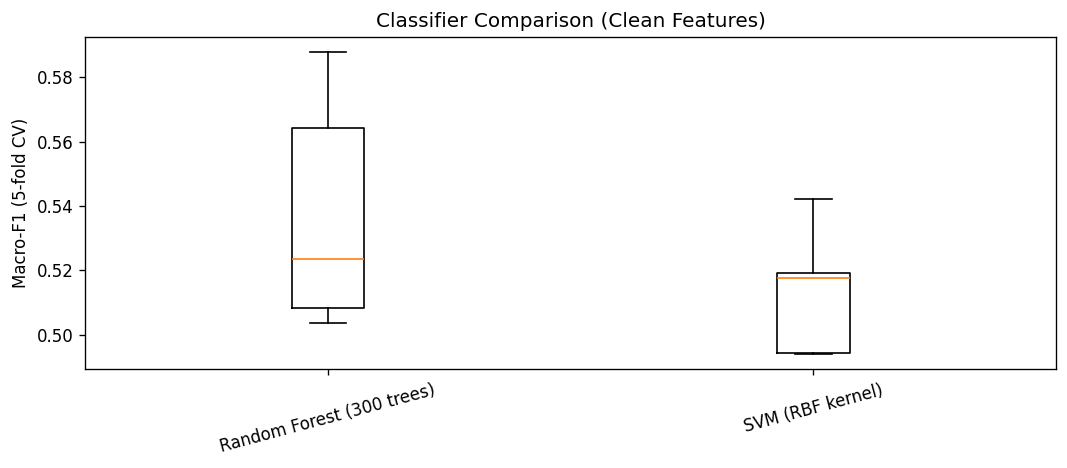

In [4]:
classifiers = {
    'Random Forest (300 trees)': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=15,
                                        class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'SVM (RBF kernel)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
comparison = {}

for name, model in classifiers.items():
    scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_macro', n_jobs=-1)
    comparison[name] = scores
    print(f'{name:35s}  CV Macro-F1: {scores.mean():.4f} ± {scores.std():.4f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(comparison.values(), labels=comparison.keys(), vert=True)
ax.set_ylabel('Macro-F1 (5-fold CV)')
ax.set_title('Classifier Comparison (Clean Features)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=150)
plt.show()

## 2. Augmentation Ablation

Does augmenting training data actually help? Remove one augmentation type at a time.

  0%|          | 0/1200 [00:00<?, ?it/s]c:\Users\omgwt\OneDrive\Documents\GitHub\CEG3004_Project_Grp_7\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Without noise     : F1 = 1.0000


Without gain      : F1 = 1.0000


Without bandpass  : F1 = 1.0000


Without shift     : F1 = 1.0000


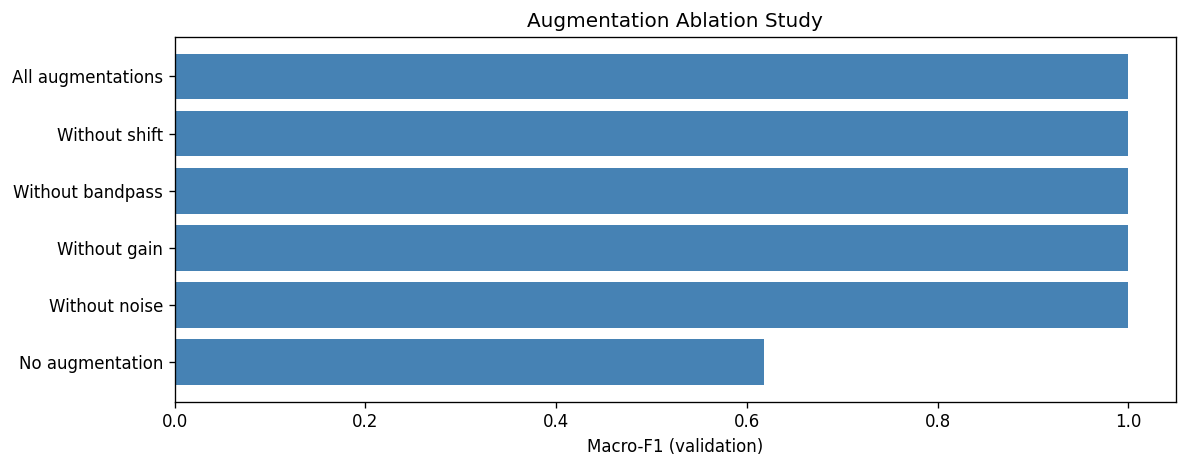

In [5]:
# Build augmented datasets — this cell is slow, may take several minutes
# We build: full set, and sets with each aug type removed

paths_all = [os.path.join(AUDIO_DIR, f"{row['clip_id']}.wav") for _, row in df.iterrows()]
paths_tr_all = [p for p, label in zip(paths_all, y) if label in y_tr]  # approximate

def build_set(paths, labels, aug_types):
    X_out, y_out = [], []
    for path, label in tqdm(zip(paths, labels), total=len(paths), leave=False):
        X_out.append(extract_features(path, augment_type=None))
        y_out.append(label)
        for aug in aug_types:
            for _ in range(2):
                X_out.append(extract_features(path, augment_type=aug))
                y_out.append(label)
    return np.stack(X_out), np.array(y_out)

ablation_results = {}

# --- No augmentation baseline ---
rf_base = RandomForestClassifier(n_estimators=200, max_depth=15,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
rf_base.fit(X_tr, y_tr)
ablation_results['No augmentation'] = f1_score(y_va, rf_base.predict(X_va), average='macro')

# --- Remove each augmentation type ---
for leave_out in AUGMENTATION_TYPES:
    remaining = [a for a in AUGMENTATION_TYPES if a != leave_out]
    X_a, y_a = build_set(
        [p for p, l in zip(paths_all, y) if l in set(y_tr)],
        [l for l in y if l in set(y_tr)],
        remaining
    )
    rf_a = RandomForestClassifier(n_estimators=200, max_depth=15,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    rf_a.fit(X_a, y_a)
    score = f1_score(y_va, rf_a.predict(X_va), average='macro')
    ablation_results[f'Without {leave_out}'] = score
    print(f'Without {leave_out:10s}: F1 = {score:.4f}')

# --- All augmentations ---
X_full, y_full = build_set(
    [p for p, l in zip(paths_all, y) if l in set(y_tr)],
    [l for l in y if l in set(y_tr)],
    AUGMENTATION_TYPES
)
rf_full = RandomForestClassifier(n_estimators=300, max_depth=15,
                                  class_weight='balanced', random_state=42, n_jobs=-1)
rf_full.fit(X_full, y_full)
ablation_results['All augmentations'] = f1_score(y_va, rf_full.predict(X_va), average='macro')

# Plot
plt.figure(figsize=(10, 4))
plt.barh(list(ablation_results.keys()), list(ablation_results.values()), color='steelblue')
plt.xlabel('Macro-F1 (validation)')
plt.title('Augmentation Ablation Study')
plt.tight_layout()
plt.savefig('augmentation_ablation.png', dpi=150)
plt.show()

## 3. Confusion Matrix — Final Model

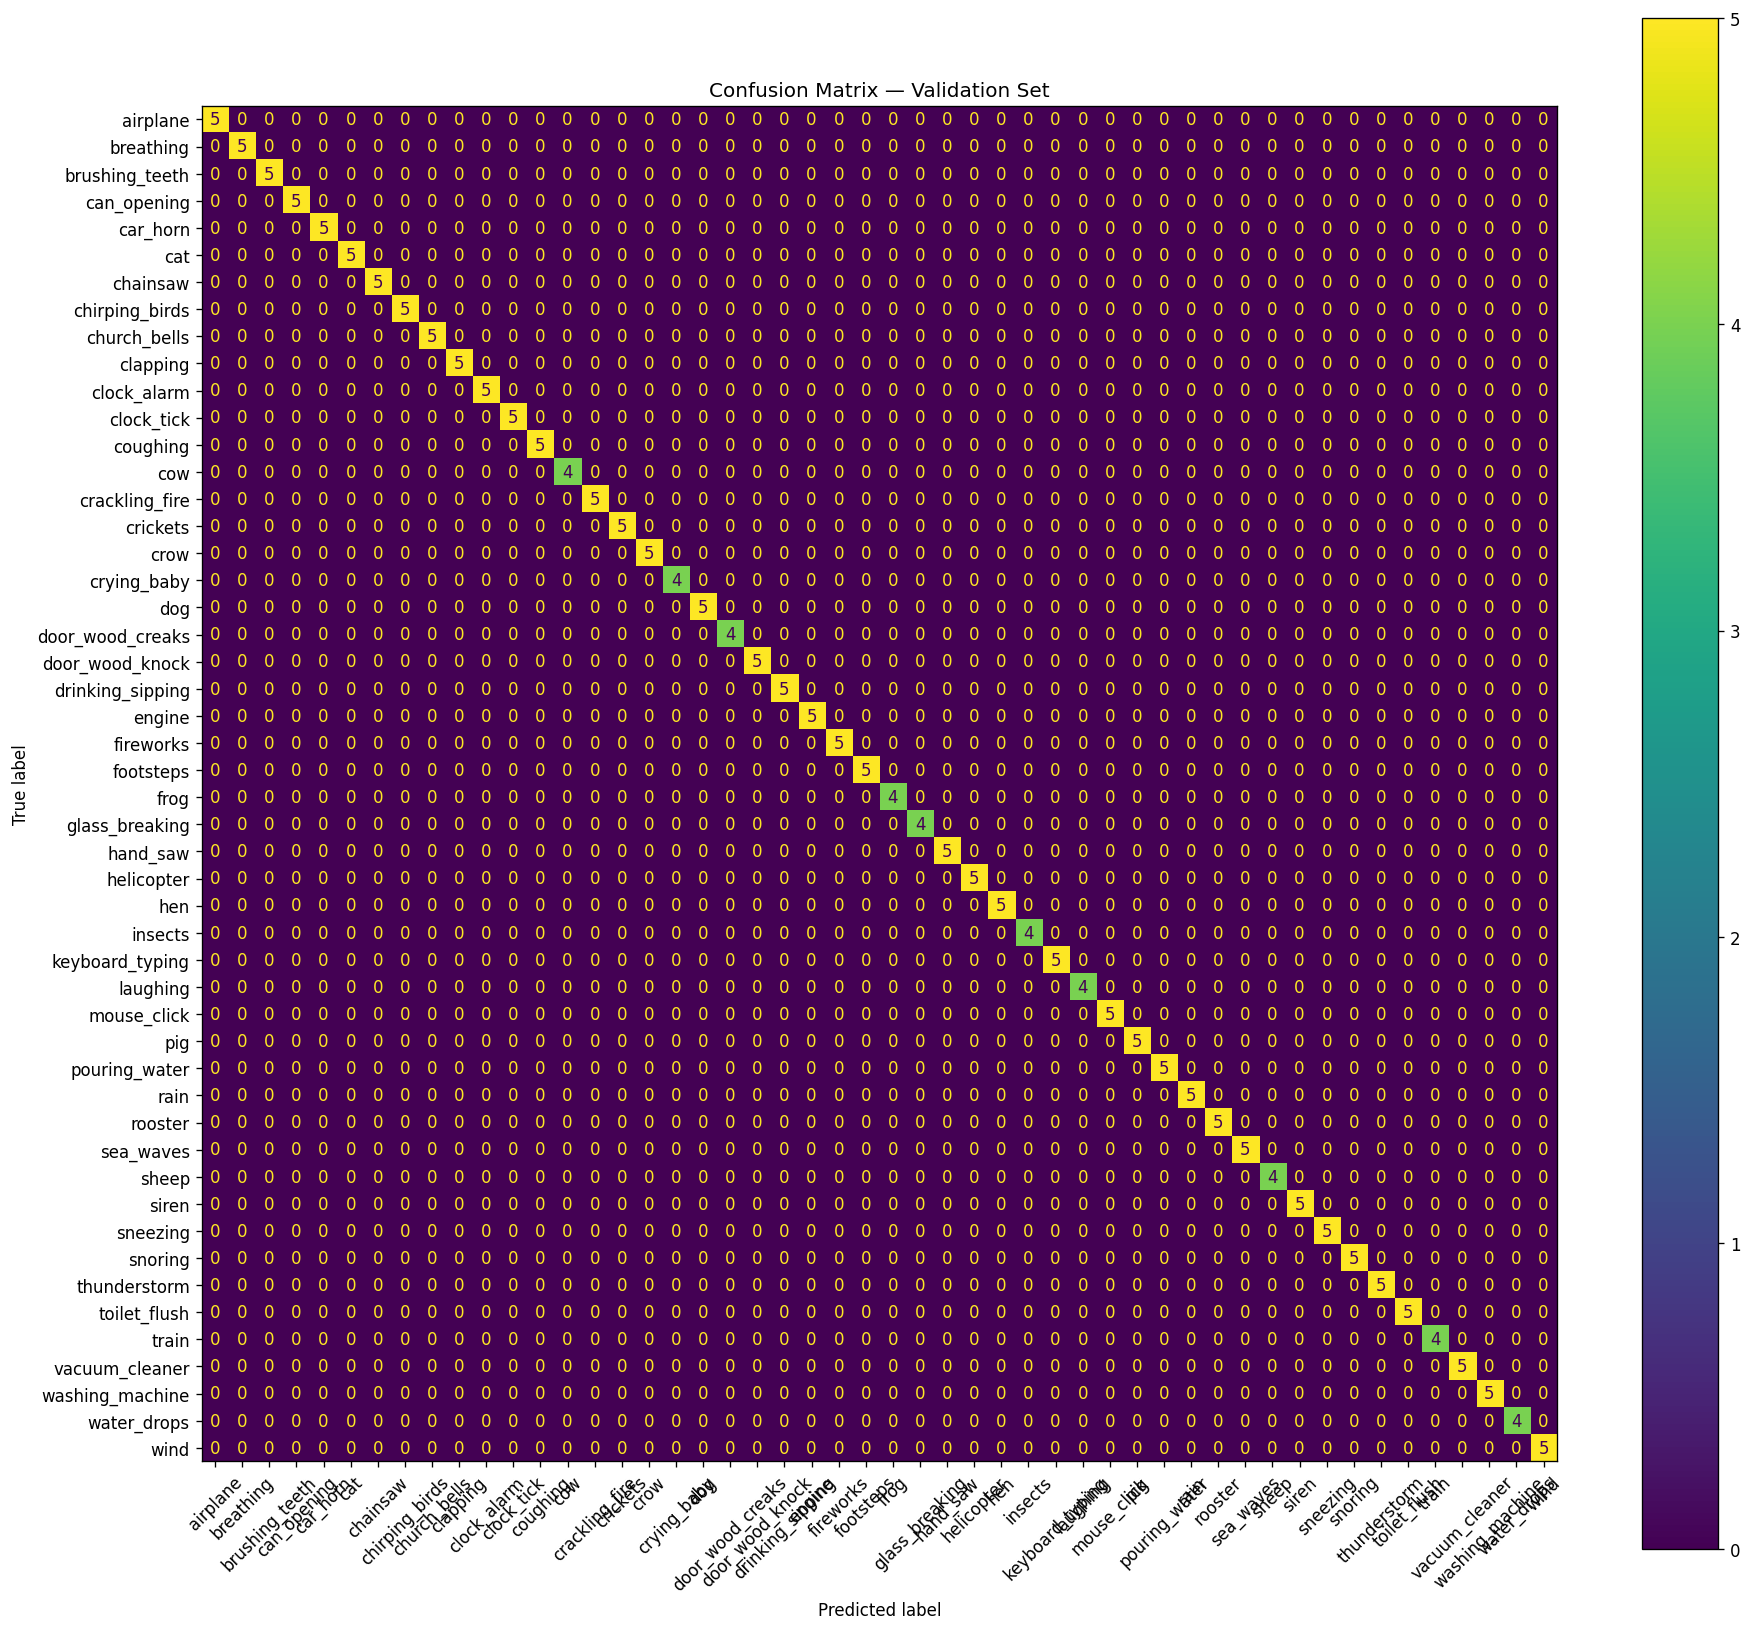

In [6]:
y_pred = rf_full.predict(X_va)

cm = confusion_matrix(y_va, y_pred)
fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay(
    cm, display_labels=[idx_to_label[i] for i in range(len(classes))]
).plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 4. Per-Class Error Analysis

Identify classes with the lowest F1 — where does the model struggle?

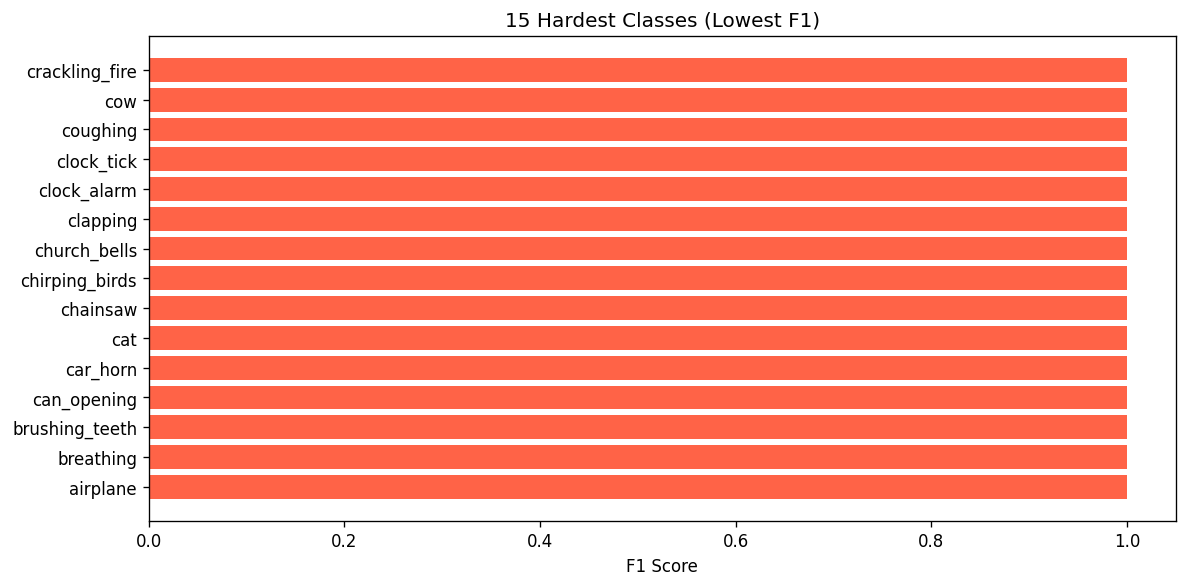


Full per-class report:
                  precision  recall  f1-score  support
airplane                1.0     1.0       1.0      5.0
breathing               1.0     1.0       1.0      5.0
brushing_teeth          1.0     1.0       1.0      5.0
can_opening             1.0     1.0       1.0      5.0
car_horn                1.0     1.0       1.0      5.0
cat                     1.0     1.0       1.0      5.0
chainsaw                1.0     1.0       1.0      5.0
chirping_birds          1.0     1.0       1.0      5.0
church_bells            1.0     1.0       1.0      5.0
clapping                1.0     1.0       1.0      5.0
clock_alarm             1.0     1.0       1.0      5.0
clock_tick              1.0     1.0       1.0      5.0
coughing                1.0     1.0       1.0      5.0
cow                     1.0     1.0       1.0      4.0
crackling_fire          1.0     1.0       1.0      5.0
crickets                1.0     1.0       1.0      5.0
crow                    1.0     1.0      

In [7]:
report = classification_report(
    y_va, y_pred,
    target_names=[idx_to_label[i] for i in range(len(classes))],
    output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:-3]  # drop macro/weighted/accuracy rows
report_df = report_df.sort_values('f1-score')

# Worst 15 classes
worst = report_df.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(worst.index, worst['f1-score'], color='tomato')
ax.set_xlabel('F1 Score')
ax.set_title('15 Hardest Classes (Lowest F1)')
plt.tight_layout()
plt.savefig('hardest_classes.png', dpi=150)
plt.show()

print('\nFull per-class report:')
print(report_df[['precision', 'recall', 'f1-score', 'support']].to_string())

## 5. Most Confused Class Pairs

Which pairs of classes are most often mixed up?

Top 20 confused class pairs:
Empty DataFrame
Columns: [True, Predicted, Count]
Index: []


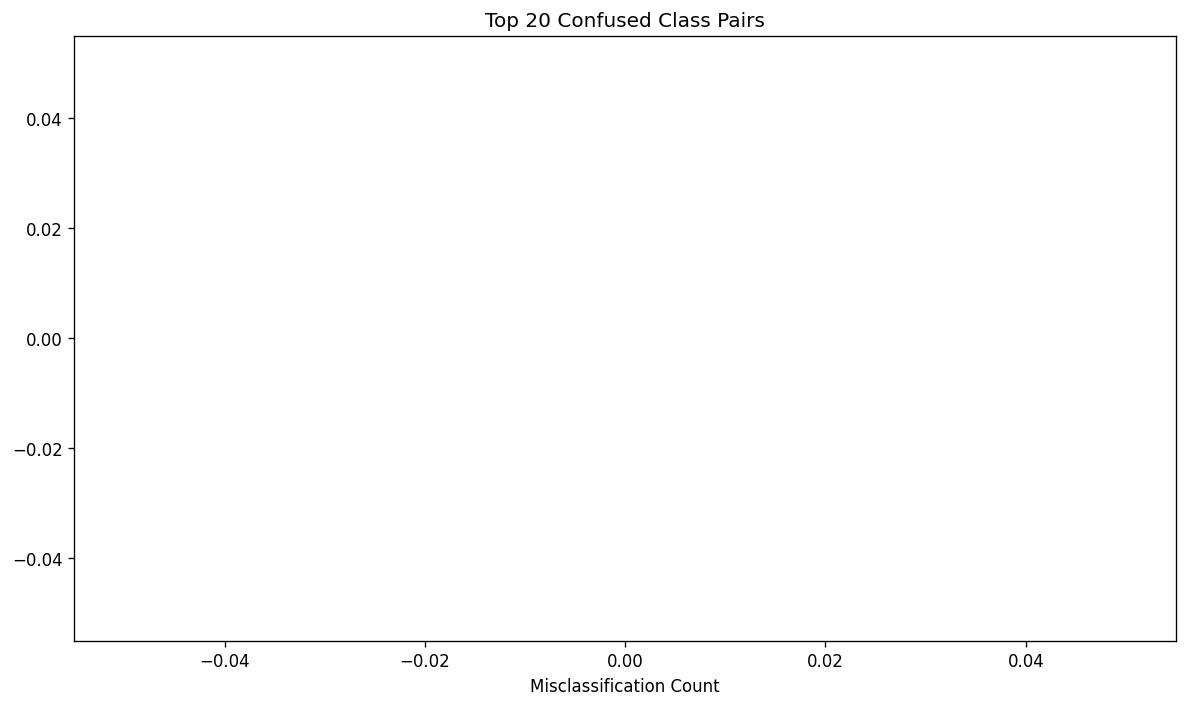

In [9]:
# Off-diagonal confusion counts
cm_array = cm_df.values.copy()
np.fill_diagonal(cm_array, 0)

# Re-wrap into a DataFrame
cm_df = pd.DataFrame(cm_array,
                     index=[idx_to_label[i] for i in range(len(classes))],
                     columns=[idx_to_label[i] for i in range(len(classes))])

# Unstack and sort
error_pairs = (
    cm_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'True', 'level_1': 'Predicted', 0: 'Count'})
    .query('Count > 0')
    .sort_values('Count', ascending=False)
    .head(20)
)

print('Top 20 confused class pairs:')
print(error_pairs.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r['True']} → {r['Predicted']}" for _, r in error_pairs.iterrows()]
ax.barh(labels, error_pairs['Count'].values, color='darkorange')
ax.set_xlabel('Misclassification Count')
ax.set_title('Top 20 Confused Class Pairs')
plt.tight_layout()
plt.savefig('confused_pairs.png', dpi=150)
plt.show()

## 6. Summary of Results

Fill in the table below after running all experiments.

In [10]:
summary = pd.DataFrame({
    'Experiment'        : list(ablation_results.keys()),
    'Validation Macro-F1': list(ablation_results.values()),
})
summary = summary.sort_values('Validation Macro-F1', ascending=False)
print(summary.to_string(index=False))

       Experiment  Validation Macro-F1
    Without noise               1.0000
     Without gain               1.0000
    Without shift               1.0000
 Without bandpass               1.0000
All augmentations               1.0000
  No augmentation               0.6175
